In [142]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import math

In [143]:
def ode_system(t, y, l):
    x = y[0]
    x_dot = y[1]
    x_ddot_cos = -(9.8)/(l)*(np.cos(x))
    return [x_dot, x_ddot_cos]
    
def ode_system2(t, y, l):
    x = y[0]
    x_dot = y[1]
    x_ddot_taylor = -(9.8)/(l)*(1 
        - np.power(x,2)/2 
        + np.power(x, 4)/math.factorial(4) 
        - np.power(x, 6)/math.factorial(6) 
        + np.power(x, 8)/math.factorial(8)
        - np.power(x, 10)/math.factorial(10)
        + np.power(x, 12)/math.factorial(12)
        - np.power(x, 14)/math.factorial(14)
        + np.power(x, 16)/math.factorial(16)
        - np.power(x, 18)/math.factorial(18)
        + np.power(x, 20)/math.factorial(20)
        - np.power(x, 22)/math.factorial(22)
        + np.power(x, 24)/math.factorial(24)
        - np.power(x, 26)/math.factorial(26)
        + np.power(x, 28)/math.factorial(28)
        )
    return [x_dot, x_ddot_taylor]

In [191]:
def solve_diff_eq(l, x0, xdot0, t_span, method='rk45', num_points=10000):
    t_eval = np.linspace(t_span[0], t_span[1], num_points)
    sol = solve_ivp(
        ode_system,
        t_span,
        [x0, xdot0],
        args=(l,),
        t_eval=t_eval,
        dense_output=True
    )
    return sol
    
def solve_diff_eq2(l, x0, xdot0, t_span, method='rk45', num_points=10000):
    t_eval = np.linspace(t_span[0], t_span[1], num_points)
    sol = solve_ivp(
        ode_system2,
        t_span,
        [x0, xdot0],
        args=(l,),
        t_eval=t_eval,
        dense_output=True
    )
    return sol

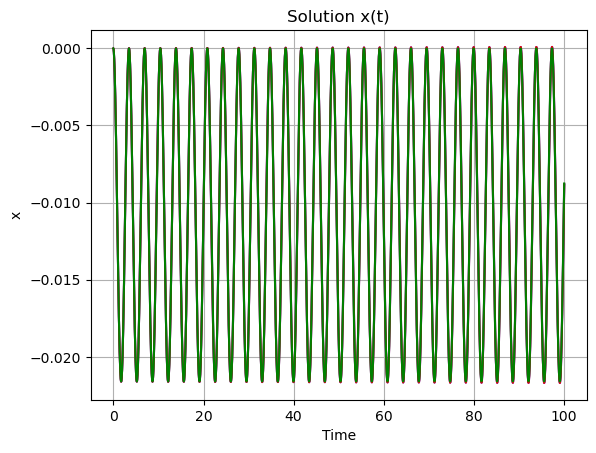

'\n# Plot x\'(t)\nplt.figure()\nplt.plot(t_vals, xdot_vals)\nplt.title("Solution x\'(t)")\nplt.xlabel("Time")\nplt.ylabel("x\'")\nplt.grid(True)\nplt.show()\n'

In [209]:
# Initial conditions
x0 = -1.56 # initial position
xdot0 = 0  # initial velocity
l = 3

# Time interval to solve over
t_start = 0
t_end = 100
t_span = (t_start, t_end)

#match to cosine
points = 10000
compare = (np.abs(x0+np.pi/2))*np.cos((np.sqrt(9.81/l)*np.linspace(t_start, t_end, points))) - (np.pi/2 + x0)
time_compare = np.arange(t_start, t_end, (t_end - t_start)/points)
# Solve the system
solution = solve_diff_eq(l, x0, xdot0, t_span)
solution2 = solve_diff_eq2(l, x0, xdot0, t_span)
# Extract time and solution arrays
t_vals = solution.t
x_vals = solution.y[0] - x0
xdot_vals = solution.y[1]
t_vals2 = solution2.t
x_vals2 = solution2.y[0] - x0
xdot_vals2 = solution.y[1]

# Plot x(t)
plt.figure()
plt.plot(t_vals, x_vals, color='blue')
plt.plot(t_vals2, x_vals2, color='red')
plt.plot(time_compare, compare, color='green')
plt.title("Solution x(t)")
plt.xlabel("Time")
plt.ylabel("x")
plt.grid(True)
plt.show()
"""
# Plot x'(t)
plt.figure()
plt.plot(t_vals, xdot_vals)
plt.title("Solution x'(t)")
plt.xlabel("Time")
plt.ylabel("x'")
plt.grid(True)
plt.show()
"""